In [1]:
from utils import load_data, load_wisp_region
from nmf_beta import vectorize_data, transform2D
import numpy as np
DETECTOR, FILTER = 'nrcb4', 'F150W'
cal, err, bg, mask, meta = load_data(f'cache/{DETECTOR}_{FILTER}_data.fits')
wisp_region = load_wisp_region(f'cache/{DETECTOR}_{FILTER}_wisp_regions.fits')

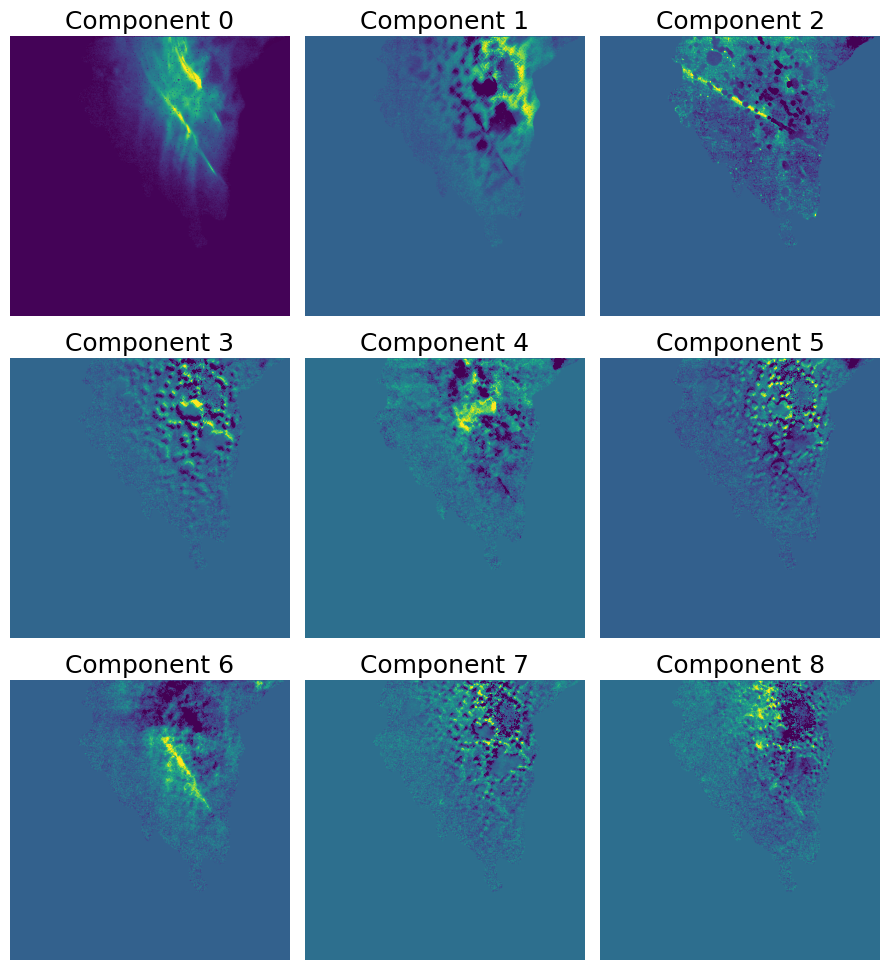

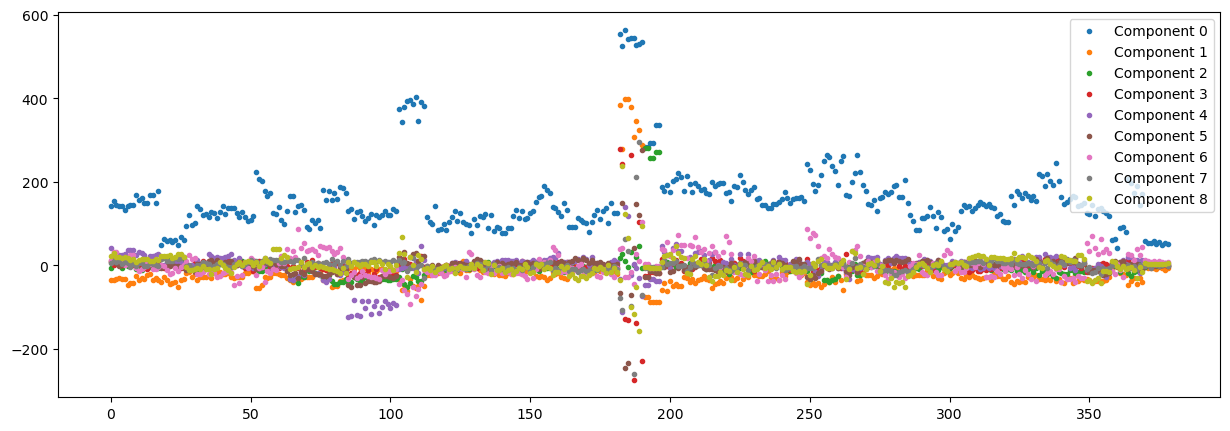

In [2]:
from utils import plot_comps, plot_amps, pca
amps, comps = pca(cal, err, mask, wisp_region)

plot_comps(comps)
plot_amps(amps, None);

[ 85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100 101 102
 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196]


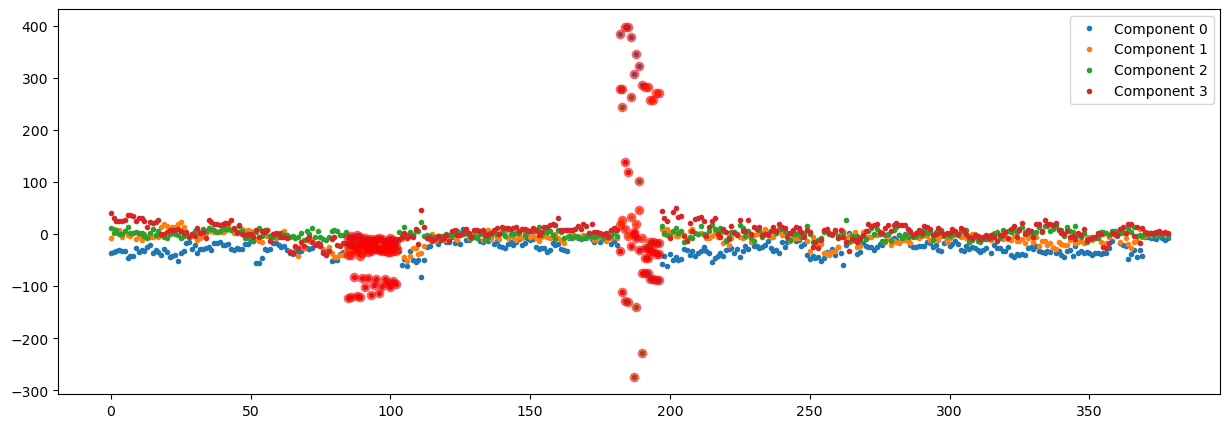

In [3]:
from nmf import identify_outliers
idx_artifacts = [1, 2, 3, 4]  # Example indices of artifacts
outliers = identify_outliers(amps[:, idx_artifacts], std_threshold=5)
print(outliers)
plot_amps(amps[:, idx_artifacts], outliers);

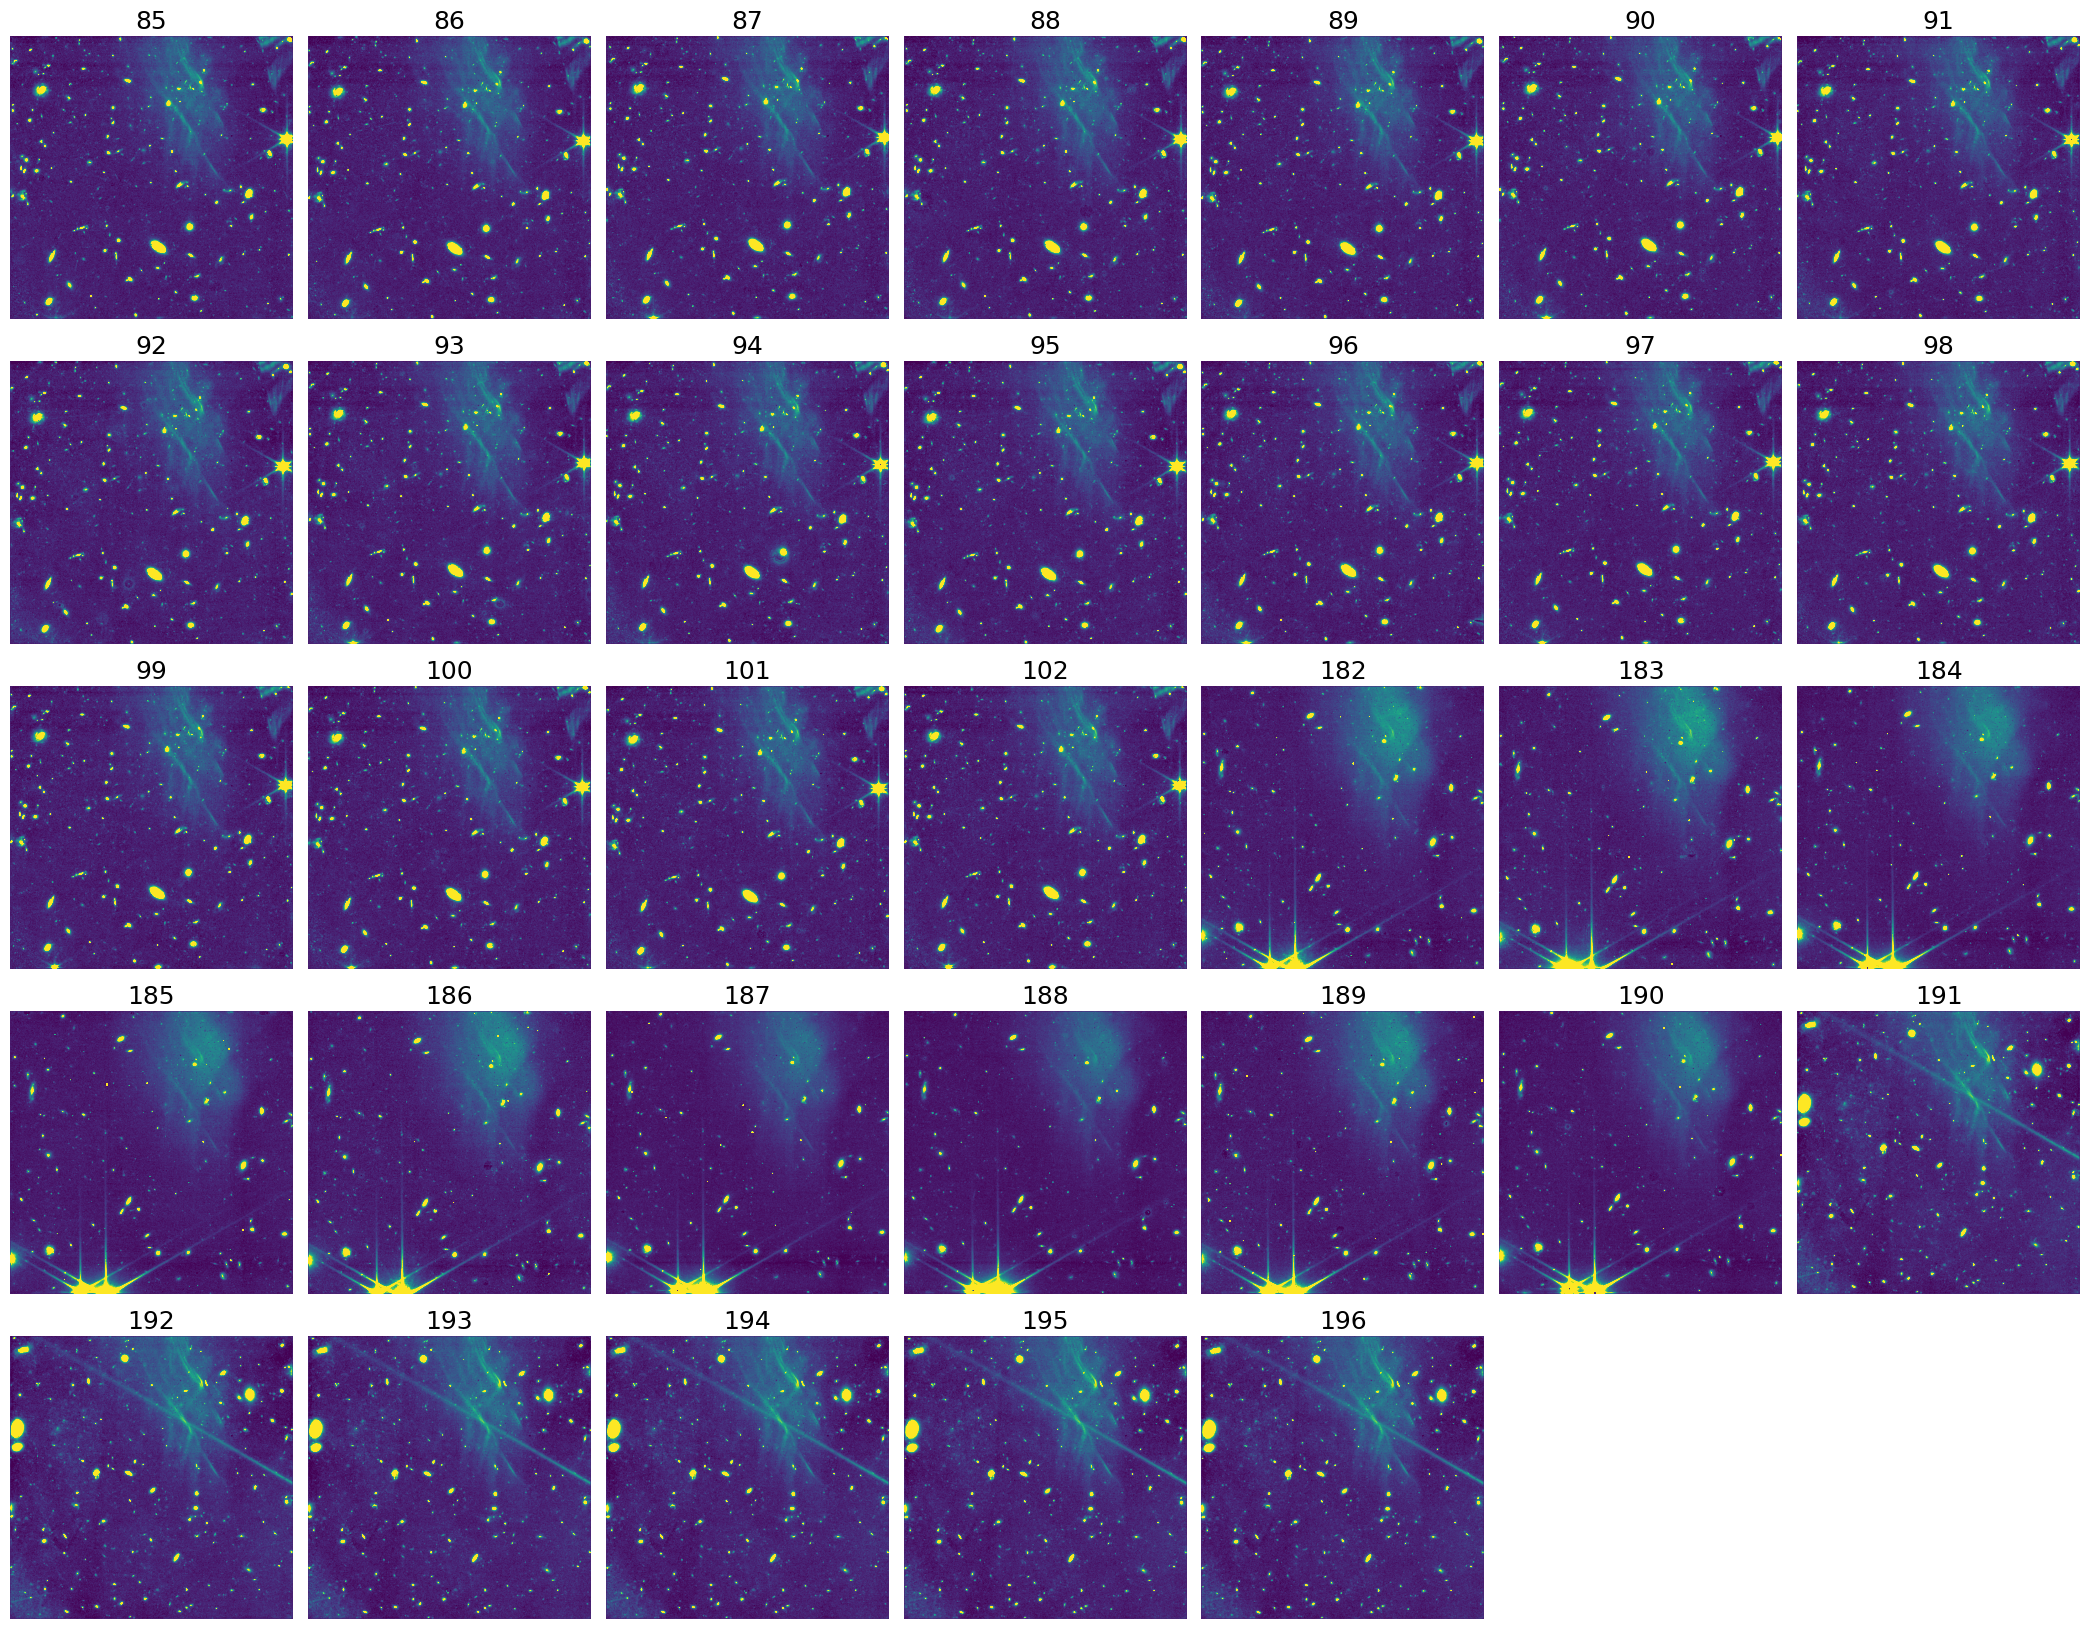

In [4]:
from utils import show_images
show_images(cal[outliers], title=outliers);

In [ ]:
from nmf_beta import nmf_iterative_correct1f

amps, templates = nmf_iterative_correct1f(cal, err, mask, wisp_region, n_comp=3, n_iter=100, outliers=outliers, verbose=True,
                                          n_iter_1f=5, split_amplifier=True)
show_images(templates, title=[f'Template {i+1}' for i in range(templates.shape[0])], cmap='magma', show_colorbar=True);

Fitting component 1/3 ... 

 86%|████████▌ | 86/100 [00:23<00:03,  3.73it/s]

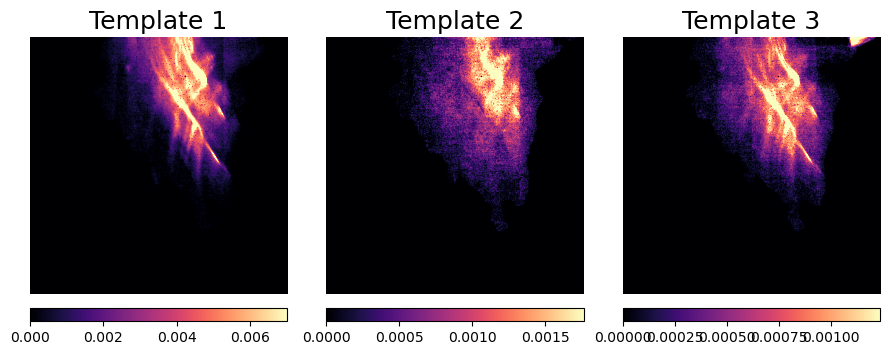

In [ ]:
show_images(templates, title=[f'Template {i+1}' for i in range(templates.shape[0])], cmap='magma', show_colorbar=True);

In [ ]:
templates = amps
data = cal


/Users/zihaowu/Desktop/wisp_organized/make_template/postprocess.py:59: RuntimeWarning: divide by zero encountered in reciprocal
  noise_power = invVar**(-1)


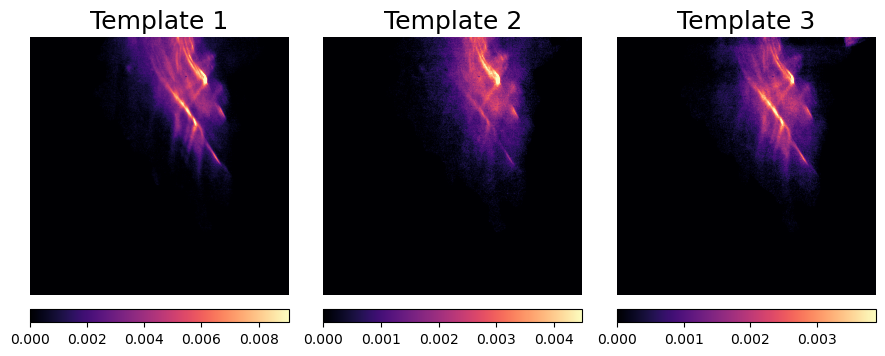

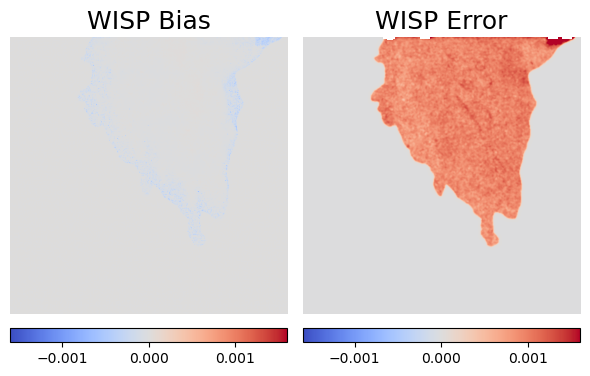

In [ ]:
# post-process templates
# from postprocess import interpolate_wisp_nans, estimate_errors
from scipy.ndimage import binary_fill_holes
from postprocess import interpolate_wisp_nans, estimate_errors
nan_pixels = np.sum(mask, axis=0) >= cal.shape[0]-2
templates = interpolate_wisp_nans(templates, nan_pixels)
residual = data - amps @ comps
wisp_bias, wisp_err = estimate_errors(residual, invVar, outliers, selected_pixels, nan_pixels)
primary = templates[0]
wisp_mask = np.zeros_like(primary, dtype=bool)
wisp_mask[selected_pixels] = True
wisp_mask = binary_fill_holes(wisp_mask)
high_snr_mask = primary > np.std((primary[primary>0]))

# show results
show_images(templates, title=[f'Template {i+1}' for i in range(templates.shape[0])], 
            cmap='magma', vlim=(1., 99.95), show_colorbar=True);
show_images([wisp_bias, wisp_err], title=['WISP Bias', 'WISP Error'], 
            cmap='coolwarm', vlim_value=(-0.0016, 0.0016), show_colorbar=True);

In [ ]:
# save templates
from astropy.io import fits
import os
output_folder = 'templates'
os.makedirs(output_folder, exist_ok=True)
hdu_list = fits.HDUList([fits.PrimaryHDU()])
for i in range(templates.shape[0]):
    hdu_list.append(fits.ImageHDU(templates[i], name=f'WISP_{i+1:02d}'))
hdu_list.append(fits.ImageHDU(wisp_mask.astype(int), name='MASK'))
hdu_list.append(fits.ImageHDU(high_snr_mask.astype(int), name='MASK_HSNR'))
hdu_list.append(fits.ImageHDU(wisp_bias, name='BIAS'))
hdu_list.append(fits.ImageHDU(wisp_err, name='ERR'))
hdu_list.writeto(f'templates/{DETECTOR}_{FILTER}.fits', overwrite=True)

In [ ]:
# from nmf import nmf_basic
# from preprocess import correct_1f_noise, estimate_1f_noise

# n_iter_1f = 3

# for it in range(n_iter_1f):
#     residual = data - amps @ comps
#     noise1f = estimate_1f_noise(residual, mask | wisp_mask[None, :], split_amplifier=True)

# # n_exp, n_pix = data.shape
# # data_corrected = np.zeros_like(data)
# # stripes_all = np.zeros_like(data)
# # return W, H, stripes_all


In [ ]:
residual.shape

(379, 77238)